In [138]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve

from imblearn.over_sampling import SMOTEN

selected_df = pd.read_csv('bank_preprocessed.csv', sep=',')
selected_df

,index,age,job,marital,education,balance,month,duration,campaign,pdays,previous,poutcome,y,total_loan
0,0,30,unemployed,married,primary,1787,oct,79,few contacts,no pdays contact,no previous contact,unknown,no,no loan
1,1,33,services,married,secondary,4789,may,220,few contacts,old,medium contacts,failure,no,2 loans
2,2,35,management,single,tertiary,1350,apr,185,few contacts,old,few contacts,failure,no,1 loan
3,3,30,management,married,tertiary,1476,jun,199,medium contacts,no pdays contact,no previous contact,unknown,no,2 loans
4,4,59,blue-collar,married,secondary,0,may,226,few contacts,no pdays contact,no previous contact,unknown,no,1 loan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4306,4516,33,services,married,secondary,-333,jul,329,medium contacts,no pdays contact,no previous contact,unknown,no,1 loan
4307,4517,57,self-employed,married,tertiary,-3313,may,153,few contacts,no pdays contact,no previous contact,unknown,no,2 loans
4308,4518,57,technician,married,secondary,295,aug,151,many contacts,no pdays contact,no previous contact,unknown,no,no loan
4309,4519,28,blue-collar,married,secondary,1137,feb,129,medium contacts,old,medium contacts,other,no,no loan


In [139]:
selected_df.drop(
    columns=['index'],inplace=True)

selected_df['y'] = selected_df['y'].map({'no': 0, 'yes': 1})

df_x = selected_df.drop(columns=['y'])
df_y = selected_df['y']


print(df_x)


      age            job  marital  education  balance month  duration  \
0      30     unemployed  married    primary     1787   oct        79   
1      33       services  married  secondary     4789   may       220   
2      35     management   single   tertiary     1350   apr       185   
3      30     management  married   tertiary     1476   jun       199   
4      59    blue-collar  married  secondary        0   may       226   
...   ...            ...      ...        ...      ...   ...       ...   
4306   33       services  married  secondary     -333   jul       329   
4307   57  self-employed  married   tertiary    -3313   may       153   
4308   57     technician  married  secondary      295   aug       151   
4309   28    blue-collar  married  secondary     1137   feb       129   
4310   44   entrepreneur   single   tertiary     1136   apr       345   

             campaign             pdays             previous poutcome  \
0        few contacts  no pdays contact  no previo

In [140]:
test_and_train = train_test_split(
    df_x,
    df_y,
    test_size=0.2,
    random_state=42,
    stratify=df_y
)
X_train = test_and_train[0]
X_test = test_and_train [1]
y_train = test_and_train [2]
y_test  = test_and_train [3]

In [141]:

encoder = OneHotEncoder(sparse_output=False)

cat_cols = X_train.select_dtypes(include=['object']).columns

X_train_encoded = encoder.fit_transform(X_train[cat_cols])

X_test_encoded = encoder.transform(X_test[cat_cols])



C:\Users\Pars\AppData\Local\Temp\ipykernel_10052\1596192688.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object']).columns


In [142]:
X_train = X_train.drop(columns=cat_cols)
X_test = X_test.drop(columns=cat_cols)

feature_names = encoder.get_feature_names_out(cat_cols)
X_train[feature_names] = X_train_encoded
X_test[feature_names] = X_test_encoded

In [143]:
smoten = SMOTEN(random_state=42)

X_train, y_train = smoten.fit_resample(X_train, y_train)

In [144]:
print( X_train.shape[0])
print( X_test.shape[0])
print( round(y_train.mean()*100, 2))
print( round(y_test.mean()*100, 2))

6100
863
50.0
11.59


In [145]:
base_tree = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=9,
    min_samples_split=20,
    min_samples_leaf=14,
    random_state=45
)
base_tree.fit(X_train, y_train)

y_pred_base = base_tree.predict(X_test)

print("max_depth:")
print(base_tree.get_depth())
print("number of leaf:")
print(base_tree.get_n_leaves())
print("accuracy in test:")
print(round(accuracy_score(y_test, y_pred_base), 4))
print()
print(classification_report(y_test, y_pred_base, target_names=['0', '1']))

max_depth:
9
number of leaf:
109
accuracy in test:
0.8111

              precision    recall  f1-score   support

           0       0.94      0.84      0.89       763
           1       0.33      0.59      0.42       100

    accuracy                           0.81       863
   macro avg       0.63      0.72      0.65       863
weighted avg       0.87      0.81      0.83       863



In [146]:
print("accuracy in train:")
print(round(base_tree.score(X_train, y_train), 4))
print("accuracy in test:")
print(round(base_tree.score(X_test, y_test), 4))

accuracy in train:
0.8989
accuracy in test:
0.8111


In [147]:
print("Accuracy:")
print(accuracy_score(y_test, y_pred_base))
print("Error Rate:")
print(1 - accuracy_score(y_test, y_pred_base))

Accuracy:
0.8111239860950173
Error Rate:
0.18887601390498265


In [148]:
cm = confusion_matrix(y_test, y_pred_base)

cm

array([[641, 122],
       [ 41,  59]])

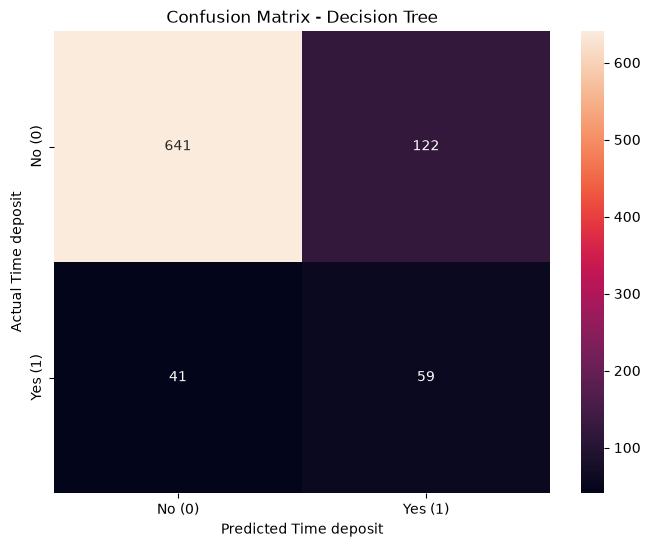

In [149]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['No (0)', 'Yes (1)'], 
            yticklabels=['No (0)', 'Yes (1)'])
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted Time deposit')
plt.ylabel('Actual Time deposit')
plt.show()

In [150]:
tn, fp, fn, tp = confusion_m.ravel()
precision = tp / (tp + fp) 
recall = tp / (tp + fn) 
f1_score = 2 * (precision * recall) / (precision + recall) 
specificity = tn / (tn + fp) 

print(f"Precision for yas {precision}")
print(f"Recall for yas {recall}")
print(f"F1: {f1_score}")
print(f"Specificity: {specificity}")

Precision for yas 0.3259668508287293
Recall for yas 0.59
F1: 0.4199288256227758
Specificity: 0.8401048492791612


In [151]:

print(classification_report(y_test, y_pred_base, target_names=[' 0 (No)', ' 1 (Yes)']))

              precision    recall  f1-score   support

      0 (No)       0.94      0.84      0.89       763
     1 (Yes)       0.33      0.59      0.42       100

    accuracy                           0.81       863
   macro avg       0.63      0.72      0.65       863
weighted avg       0.87      0.81      0.83       863



AUC-ROC Score: 0.8034600262123198


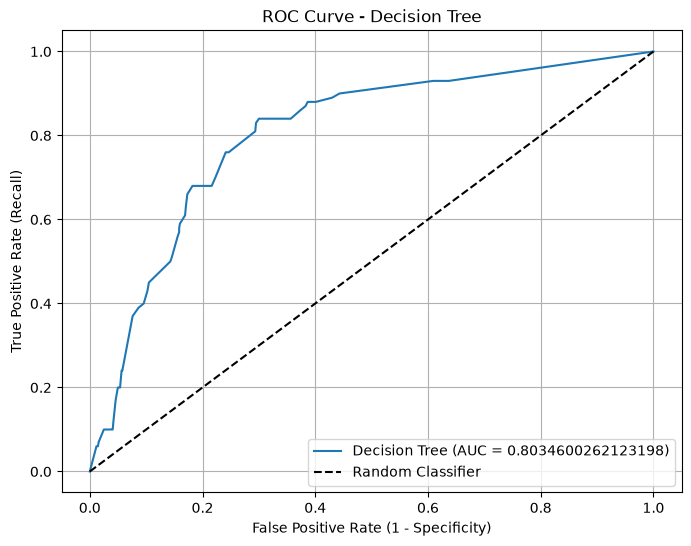

In [152]:
if hasattr(base_tree, "predict_proba"):
    y_pred_proba = base_tree.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_pred_proba)
    print(f"AUC-ROC Score: {auc_score}")

    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'Decision Tree (AUC = {auc_score})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Recall)')
    plt.title('ROC Curve - Decision Tree')
    plt.legend()
    plt.grid(True)
    plt.show()

In [153]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': base_tree.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(10))

                     feature  importance
2                   duration    0.267835
0                        age    0.184016
1                    balance    0.133801
28                 month_may    0.075779
46          poutcome_success    0.055314
25                 month_jul    0.043866
4            job_blue-collar    0.035640
21                 month_aug    0.029791
16            marital_single    0.026739
42  previous_medium contacts    0.024512


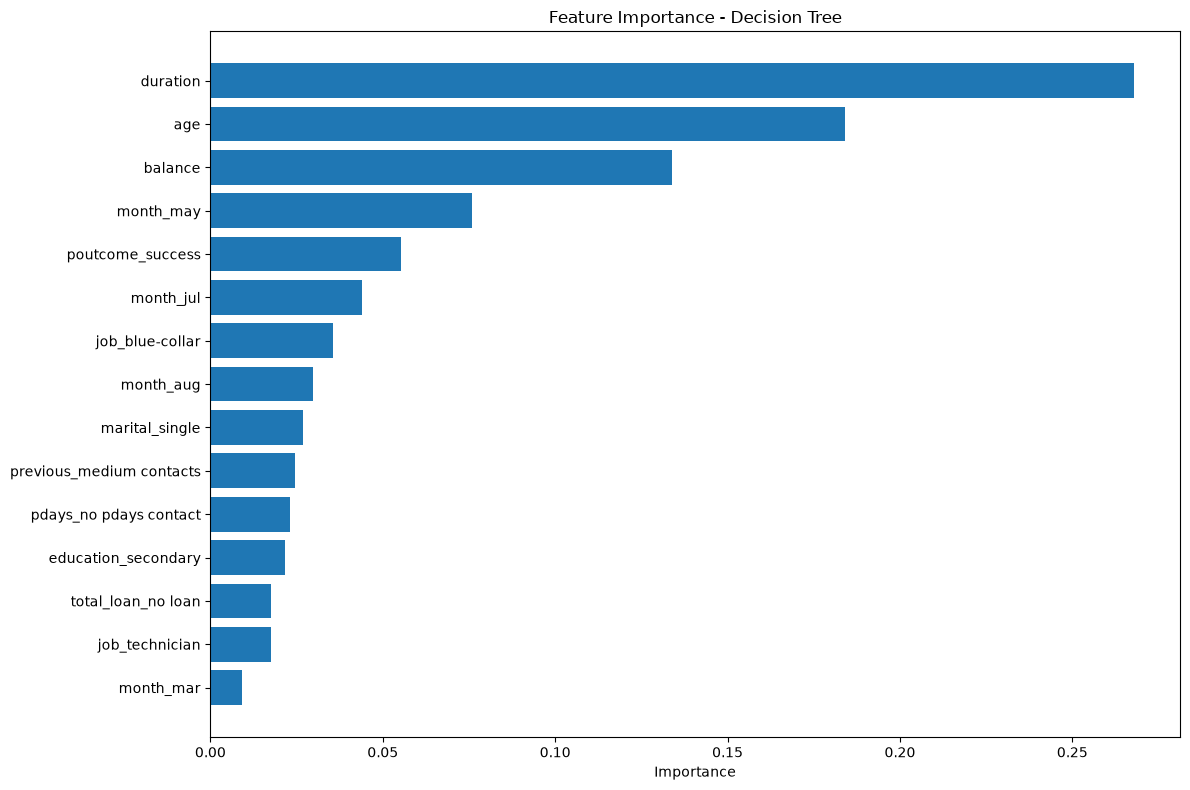

In [154]:
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance')
plt.title('Feature Importance - Decision Tree')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
